In [1]:
#Comienza el analisis de datos

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from db_utils import db_conectar
from matplotlib.ticker import FuncFormatter
conn = db_conectar()

In [3]:
#Seteamos las conexiones para evitar tener que escrbir todo el tiempo joins y demas
#Tambien definimos las constantes para facilitar el analisis
query = """
SELECT 
    f.ID_ENCUESTADO,
    f.EDAD,
    f.ANIOS_EXPERIENCIA,
    f.ANTIGUEDAD_EMPRESA,
    f.TIEMPO_PUESTO,
    f.SALARIO_REAL,

    f.ID_PROVINCIA,
    p.DESCRIPCION  AS PROVINCIA,

    f.ID_SENIORITY,
    s.DESCRIPCION  AS SENIORITY,

    f.ID_GENERO,
    g.DESCRIPCION  AS GENERO,

    f.ID_TIPO_CONTRATO,
    c.DESCRIPCION  AS TIPO_CONTRATO,

    f.ID_MODALIDAD,
    m.DESCRIPCION  AS MODALIDAD,

    f.ID_JORNADA,
    j.DESCRIPCION  AS JORNADA,

    f.ID_NIVEL_ESTUDIOS,
    e.DESCRIPCION  AS NIVEL_ESTUDIOS,

    f.ID_RANGO_SALARIO,
    rs.DESCRIPCION AS RANGO_SALARIO,

    f.ID_SUELDO_DOLARIZADO,
    sd.DESCRIPCION AS SUELDO_DOLARIZADO,

    f.ID_BONO,
    b.DESCRIPCION  AS BONO,

    f.ID_ACTUALIZACION_SALARIAL,
    a.DESCRIPCION  AS ACTUALIZACION_SALARIAL,

    f.ID_GUARDIAS,
    gu.DESCRIPCION AS GUARDIAS,

    f.ID_SATISFACCION_INGRESOS,
    si.DESCRIPCION AS SATISFACCION_INGRESOS,

    f.ID_BUSCANDO_TRABAJO,
    bt.DESCRIPCION AS BUSCANDO_TRABAJO

FROM Gold.TBL_ENCUESTADOS_GOLD f
LEFT JOIN Silver.TBL_PROVINCIA              p  ON p.ID = f.ID_PROVINCIA
LEFT JOIN Silver.TBL_SENIORITY              s  ON s.ID = f.ID_SENIORITY
LEFT JOIN Silver.TBL_GENERO                 g  ON g.ID = f.ID_GENERO
LEFT JOIN Silver.TBL_CONTRATO               c  ON c.ID = f.ID_TIPO_CONTRATO
LEFT JOIN Silver.TBL_MODALIDAD              m  ON m.ID = f.ID_MODALIDAD
LEFT JOIN Silver.TBL_JORNADA                j  ON j.ID = f.ID_JORNADA
LEFT JOIN Silver.TBL_ESTUDIOS               e  ON e.ID = f.ID_NIVEL_ESTUDIOS
LEFT JOIN Gold.TBL_RANGO_SALARIO            rs ON rs.ID_RANGO_SALARIO = f.ID_RANGO_SALARIO
LEFT JOIN Silver.TBL_SUELDO_DOLARIZADO      sd ON sd.ID = f.ID_SUELDO_DOLARIZADO
LEFT JOIN Silver.TBL_BONO                   b  ON b.ID = f.ID_BONO
LEFT JOIN Silver.TBL_ACTUALIZACION_SALARIAL a  ON a.ID = f.ID_ACTUALIZACION_SALARIAL
LEFT JOIN Silver.TBL_GUARDIAS               gu ON gu.ID = f.ID_GUARDIAS
LEFT JOIN Silver.TBL_SATISFACCION_INGRESOS  si ON si.ID = f.ID_SATISFACCION_INGRESOS
LEFT JOIN Silver.TBL_BUSCANDO_TRABAJO       bt ON bt.ID = f.ID_BUSCANDO_TRABAJO;
"""

df = pd.read_sql(query, conn)
print("Dimensiones:", df.shape)
print("Columnas:", df.columns.tolist())
df.head()

C:\Users\54112\AppData\Local\Temp\ipykernel_25284\1464615256.py:71: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Dimensiones: (8171, 34)
Columnas: ['ID_ENCUESTADO', 'EDAD', 'ANIOS_EXPERIENCIA', 'ANTIGUEDAD_EMPRESA', 'TIEMPO_PUESTO', 'SALARIO_REAL', 'ID_PROVINCIA', 'PROVINCIA', 'ID_SENIORITY', 'SENIORITY', 'ID_GENERO', 'GENERO', 'ID_TIPO_CONTRATO', 'TIPO_CONTRATO', 'ID_MODALIDAD', 'MODALIDAD', 'ID_JORNADA', 'JORNADA', 'ID_NIVEL_ESTUDIOS', 'NIVEL_ESTUDIOS', 'ID_RANGO_SALARIO', 'RANGO_SALARIO', 'ID_SUELDO_DOLARIZADO', 'SUELDO_DOLARIZADO', 'ID_BONO', 'BONO', 'ID_ACTUALIZACION_SALARIAL', 'ACTUALIZACION_SALARIAL', 'ID_GUARDIAS', 'GUARDIAS', 'ID_SATISFACCION_INGRESOS', 'SATISFACCION_INGRESOS', 'ID_BUSCANDO_TRABAJO', 'BUSCANDO_TRABAJO']


,ID_ENCUESTADO,EDAD,ANIOS_EXPERIENCIA,ANTIGUEDAD_EMPRESA,TIEMPO_PUESTO,SALARIO_REAL,ID_PROVINCIA,PROVINCIA,ID_SENIORITY,SENIORITY,...,ID_BONO,BONO,ID_ACTUALIZACION_SALARIAL,ACTUALIZACION_SALARIAL,ID_GUARDIAS,GUARDIAS,ID_SATISFACCION_INGRESOS,SATISFACCION_INGRESOS,ID_BUSCANDO_TRABAJO,BUSCANDO_TRABAJO
0,1,25,3,0,0,3094042.59,1,Buenos Aires,2,Semi-Senior,...,2,No,2,No,3,No,4,Muy conforme,2,"No, estoy muy conforme."
1,2,27,2,1,1,1717411.98,1,Buenos Aires,1,Junior,...,2,No,1,Si,3,No,2,Disconforme,3,"No, pero escucho ofertas."
2,3,21,0,0,0,691336.39,1,Buenos Aires,1,Junior,...,2,No,2,No,3,No,2,Disconforme,3,"No, pero escucho ofertas."
3,4,25,3,1,1,2214680.81,1,Buenos Aires,2,Semi-Senior,...,1,Si,1,Si,3,No,2,Disconforme,2,"No, estoy muy conforme."
4,6,38,12,1,1,1600315.71,2,Córdoba,3,Senior,...,2,No,1,Si,3,No,4,Muy conforme,3,"No, pero escucho ofertas."


Analisis de Salario promedio por provincia

Este grafico es más que nada para el analisis

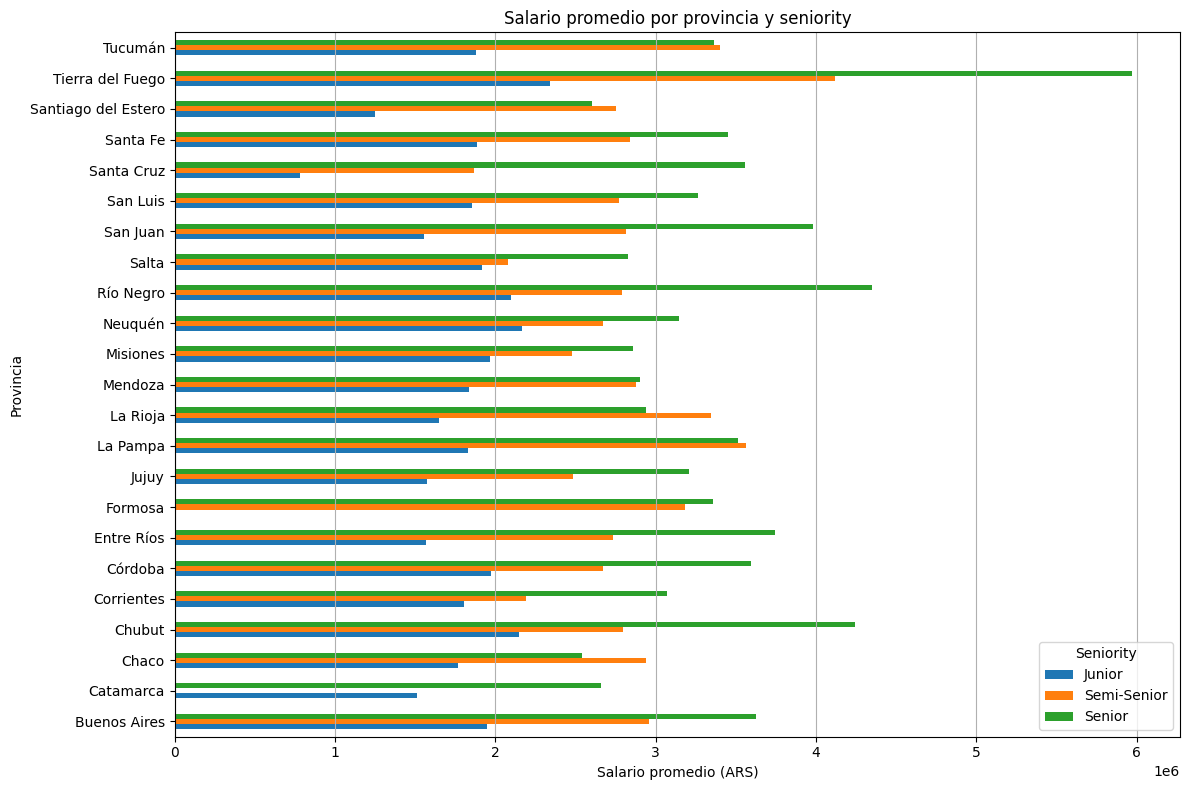

In [4]:
salarios_por_provincia = df.groupby("PROVINCIA")["SALARIO_REAL"].mean().sort_values()

df.groupby(["PROVINCIA", "SENIORITY"])["SALARIO_REAL"].mean().unstack().plot(kind="barh", figsize=(12,8))
plt.title("Salario promedio por provincia y seniority")
plt.xlabel("Salario promedio (ARS)")
plt.ylabel("Provincia")
plt.legend(title="Seniority")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

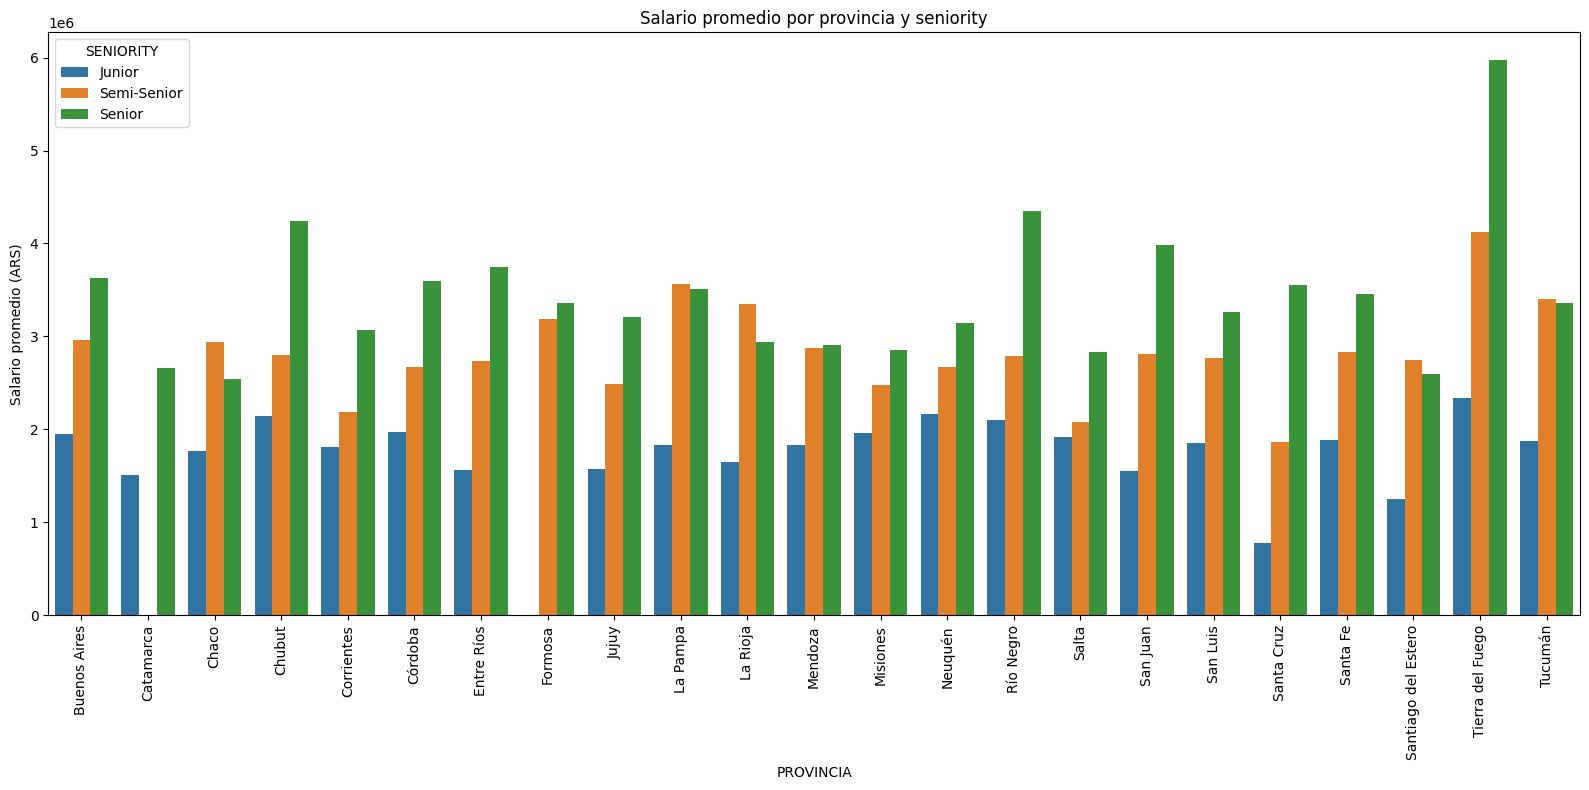

In [5]:
df_grouped = df.groupby(["PROVINCIA", "SENIORITY"])["SALARIO_REAL"].mean().reset_index()
plt.figure(figsize=(16,8))
sns.barplot(data=df_grouped, x="PROVINCIA", y="SALARIO_REAL", hue="SENIORITY")
plt.title("Salario promedio por provincia y seniority")
plt.ylabel("Salario promedio (ARS)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Estos graficos son más que nada para que el cliente lo pueda entender y pueda tener una mejor vision por seniority

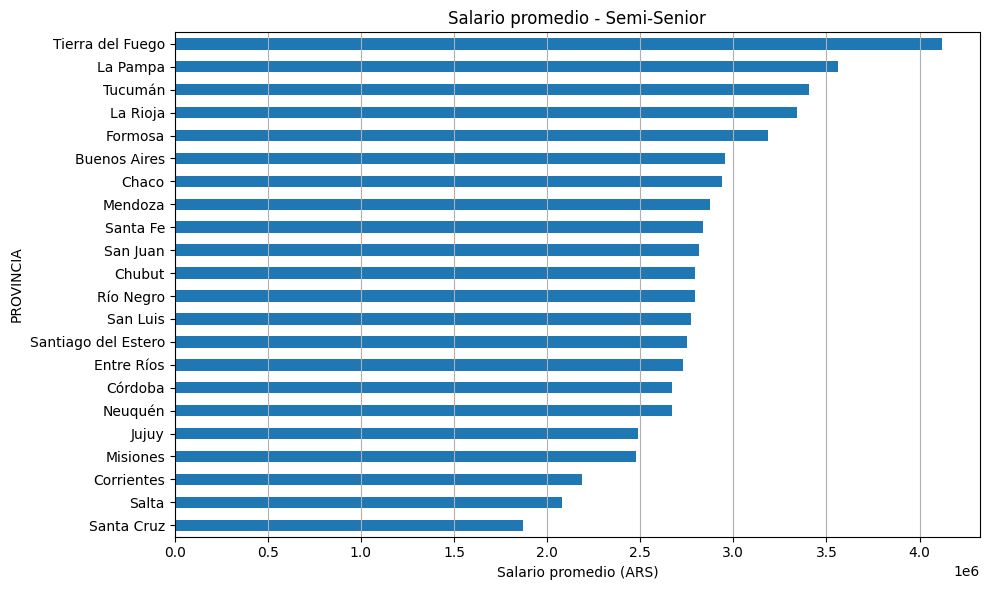

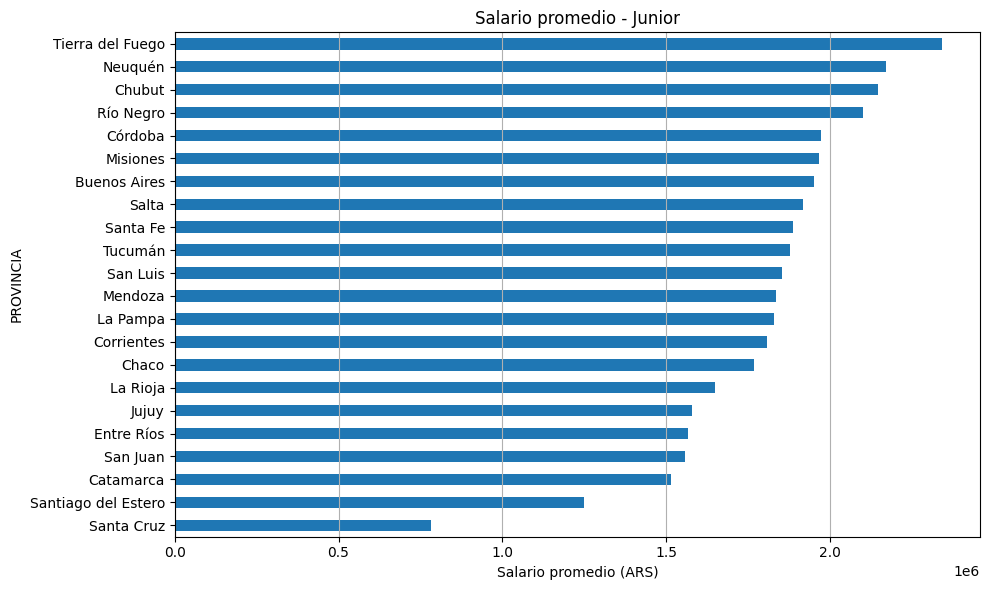

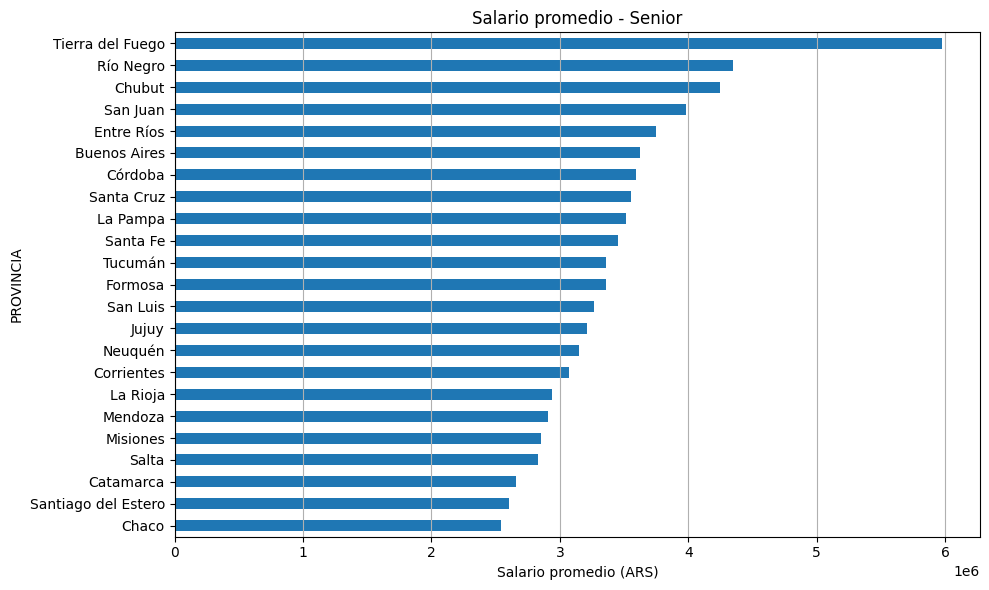

In [6]:
for seniority in df["SENIORITY"].unique():
    df_sen = df[df["SENIORITY"] == seniority]
    promedio = df_sen.groupby("PROVINCIA")["SALARIO_REAL"].mean().sort_values()

    promedio.plot(kind="barh", figsize=(10,6), title=f"Salario promedio - {seniority}")
    plt.xlabel("Salario promedio (ARS)")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.show()

Buscamos analizar el porcentaje de personas que están buscando trabajo activamente o escuchando ofertas separados por provincia.
Antigüedad promedio en la empresa por provincia o por seniority y cruzarlo con satisfacción salarial.

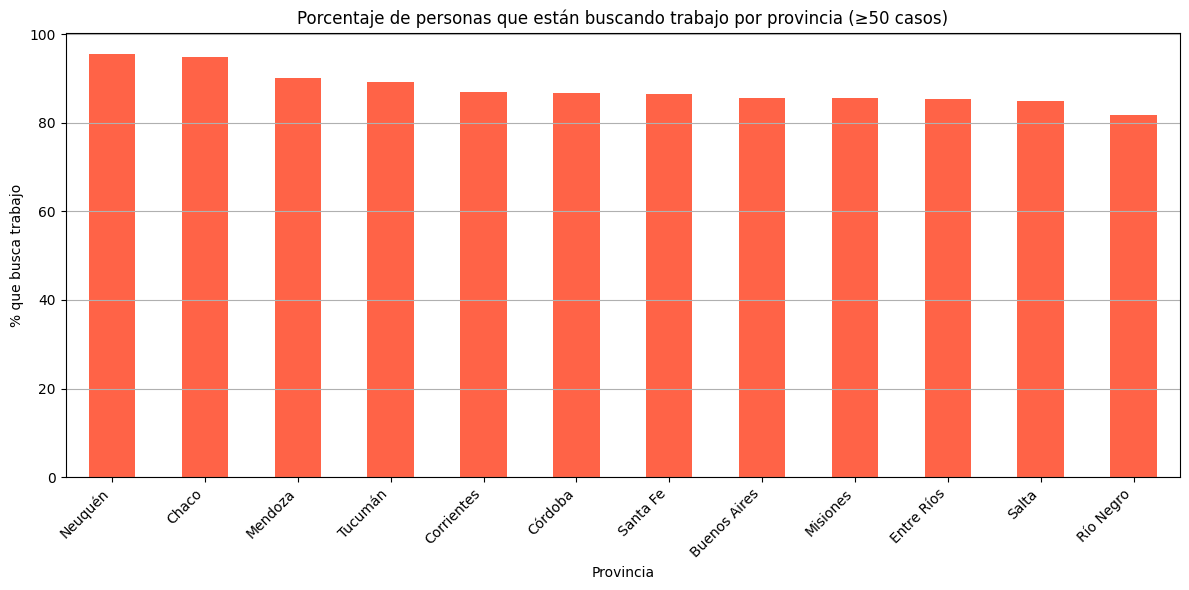

In [57]:
#Creamos una columna binaria en base al id de buscando trabajo  
df["BUSCA_TRABAJO_BIN"] = df["ID_BUSCANDO_TRABAJO"].apply(lambda x: 1 if x in [1, 3] else 0)

#Solo si tiene 30 encuestados para evitar incongruencias de 100% en 1 provinca
provincia_counts = df["PROVINCIA"].value_counts()
provincias_validas = provincia_counts[provincia_counts >= 50].index
df_filtrado = df[df["PROVINCIA"].isin(provincias_validas)]

rotacion_por_provincia = (
    df_filtrado.groupby("PROVINCIA")["BUSCA_TRABAJO_BIN"]
    .mean()
    .sort_values(ascending=False) * 100
)


plt.figure(figsize=(12, 6))
rotacion_por_provincia.plot(kind="bar", color="tomato")
plt.title("Porcentaje de personas que están buscando trabajo por provincia (≥50 casos)")
plt.ylabel("% que busca trabajo")
plt.xlabel("Provincia")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Notamos que hay un gran porcentaje de "Escucha de ofertas" pero ¿Quien realmente esta tan enfocado en escuchar ofertas? ¿Cuenta con antiguedad? ¿Juniors- Ssr-Sr?


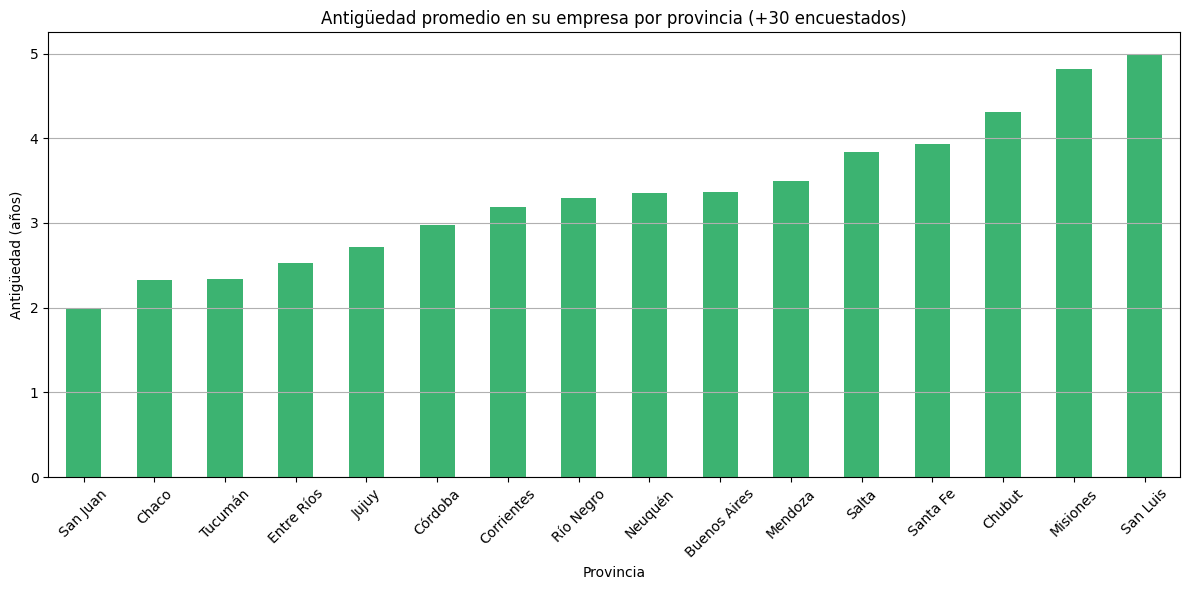

In [56]:
provincia_counts = df["PROVINCIA"].value_counts()
provincias_validas = provincia_counts[provincia_counts >= 30].index

# Filtrar el DataFrame
df_filtrado = df[df["PROVINCIA"].isin(provincias_validas)]


antiguedad_prom = df_filtrado.groupby("PROVINCIA")["ANTIGUEDAD_EMPRESA"].mean().sort_values()

plt.figure(figsize=(12, 6))
antiguedad_prom.plot(kind="bar", color="mediumseagreen")
plt.title("Antigüedad promedio en su empresa por provincia (+30 encuestados)")
plt.ylabel("Antigüedad (años)")
plt.xlabel("Provincia")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

Si bien esto no es un dato tan relevante, podriamos convertirlo en uno muy interesante si lo combinamos con otro analisis ¿Cuanto tiempo permanecen los trabajadores en sus puestos, en promedio según la provincia?
Esto nos da oro en informacion:
que tanta estabilidad tiene en la provincia,
que tan "atractivas" son las condiciones de trabajo

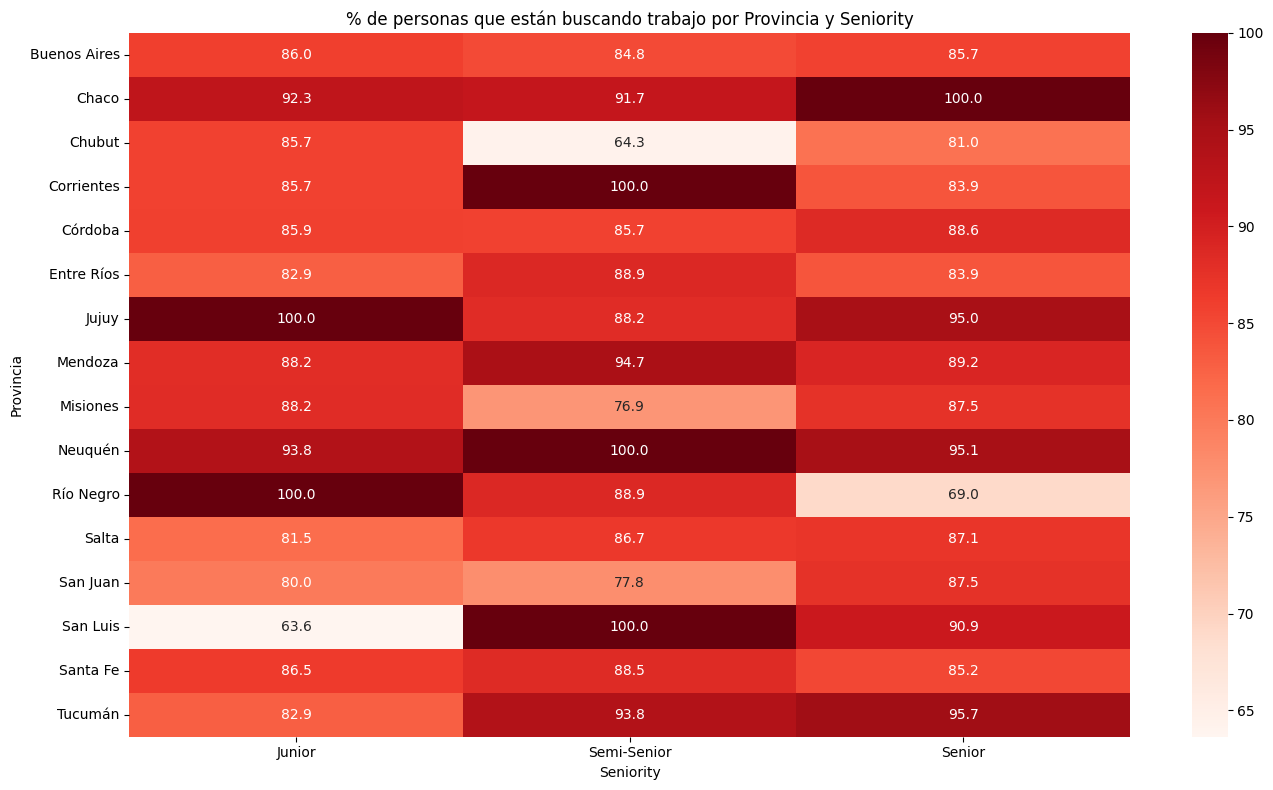

In [ ]:
# Agrupamos por provincia y seniority y calculamos % que "busca" trabajo
rotacion = df[df["PROVINCIA"].isin(provincias_validas)].groupby(["PROVINCIA", "SENIORITY"])["BUSCA_TRABAJO_BIN"].mean().unstack() * 100


plt.figure(figsize=(14, 8))
sns.heatmap(rotacion, annot=True, fmt=".1f", cmap="Reds")
plt.title("% de personas que están buscando trabajo por Provincia y Seniority")
plt.xlabel("Seniority")
plt.ylabel("Provincia")
plt.tight_layout()
plt.show()

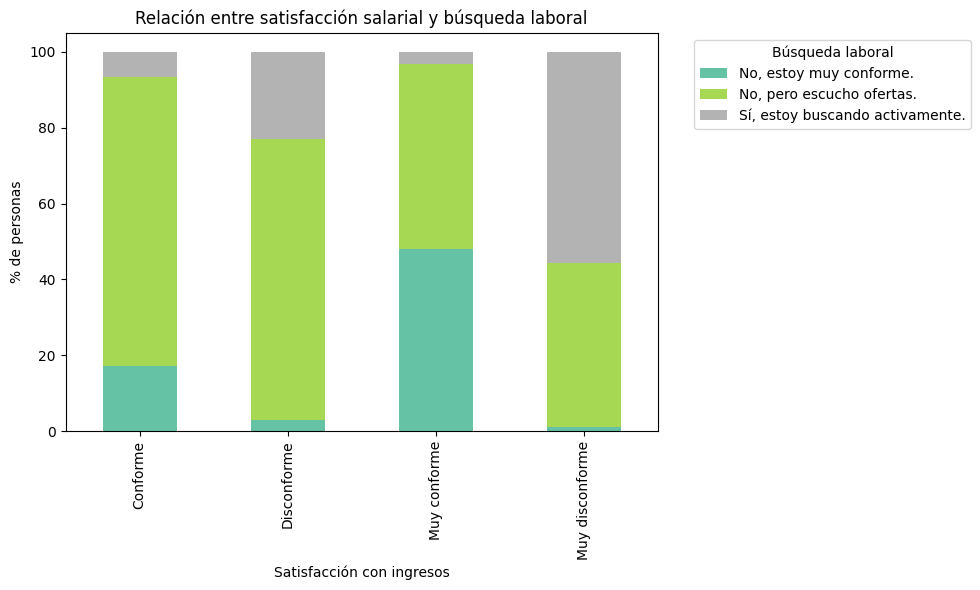

In [10]:
tabla = pd.crosstab(
    df["SATISFACCION_INGRESOS"],
    df["BUSCANDO_TRABAJO"],
    normalize="index"
) * 100

# Visualizamos
tabla.plot(kind="bar", stacked=True, figsize=(10,6), colormap="Set2")
plt.title("Relación entre satisfacción salarial y búsqueda laboral")
plt.ylabel("% de personas")
plt.xlabel("Satisfacción con ingresos")
plt.legend(title="Búsqueda laboral", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

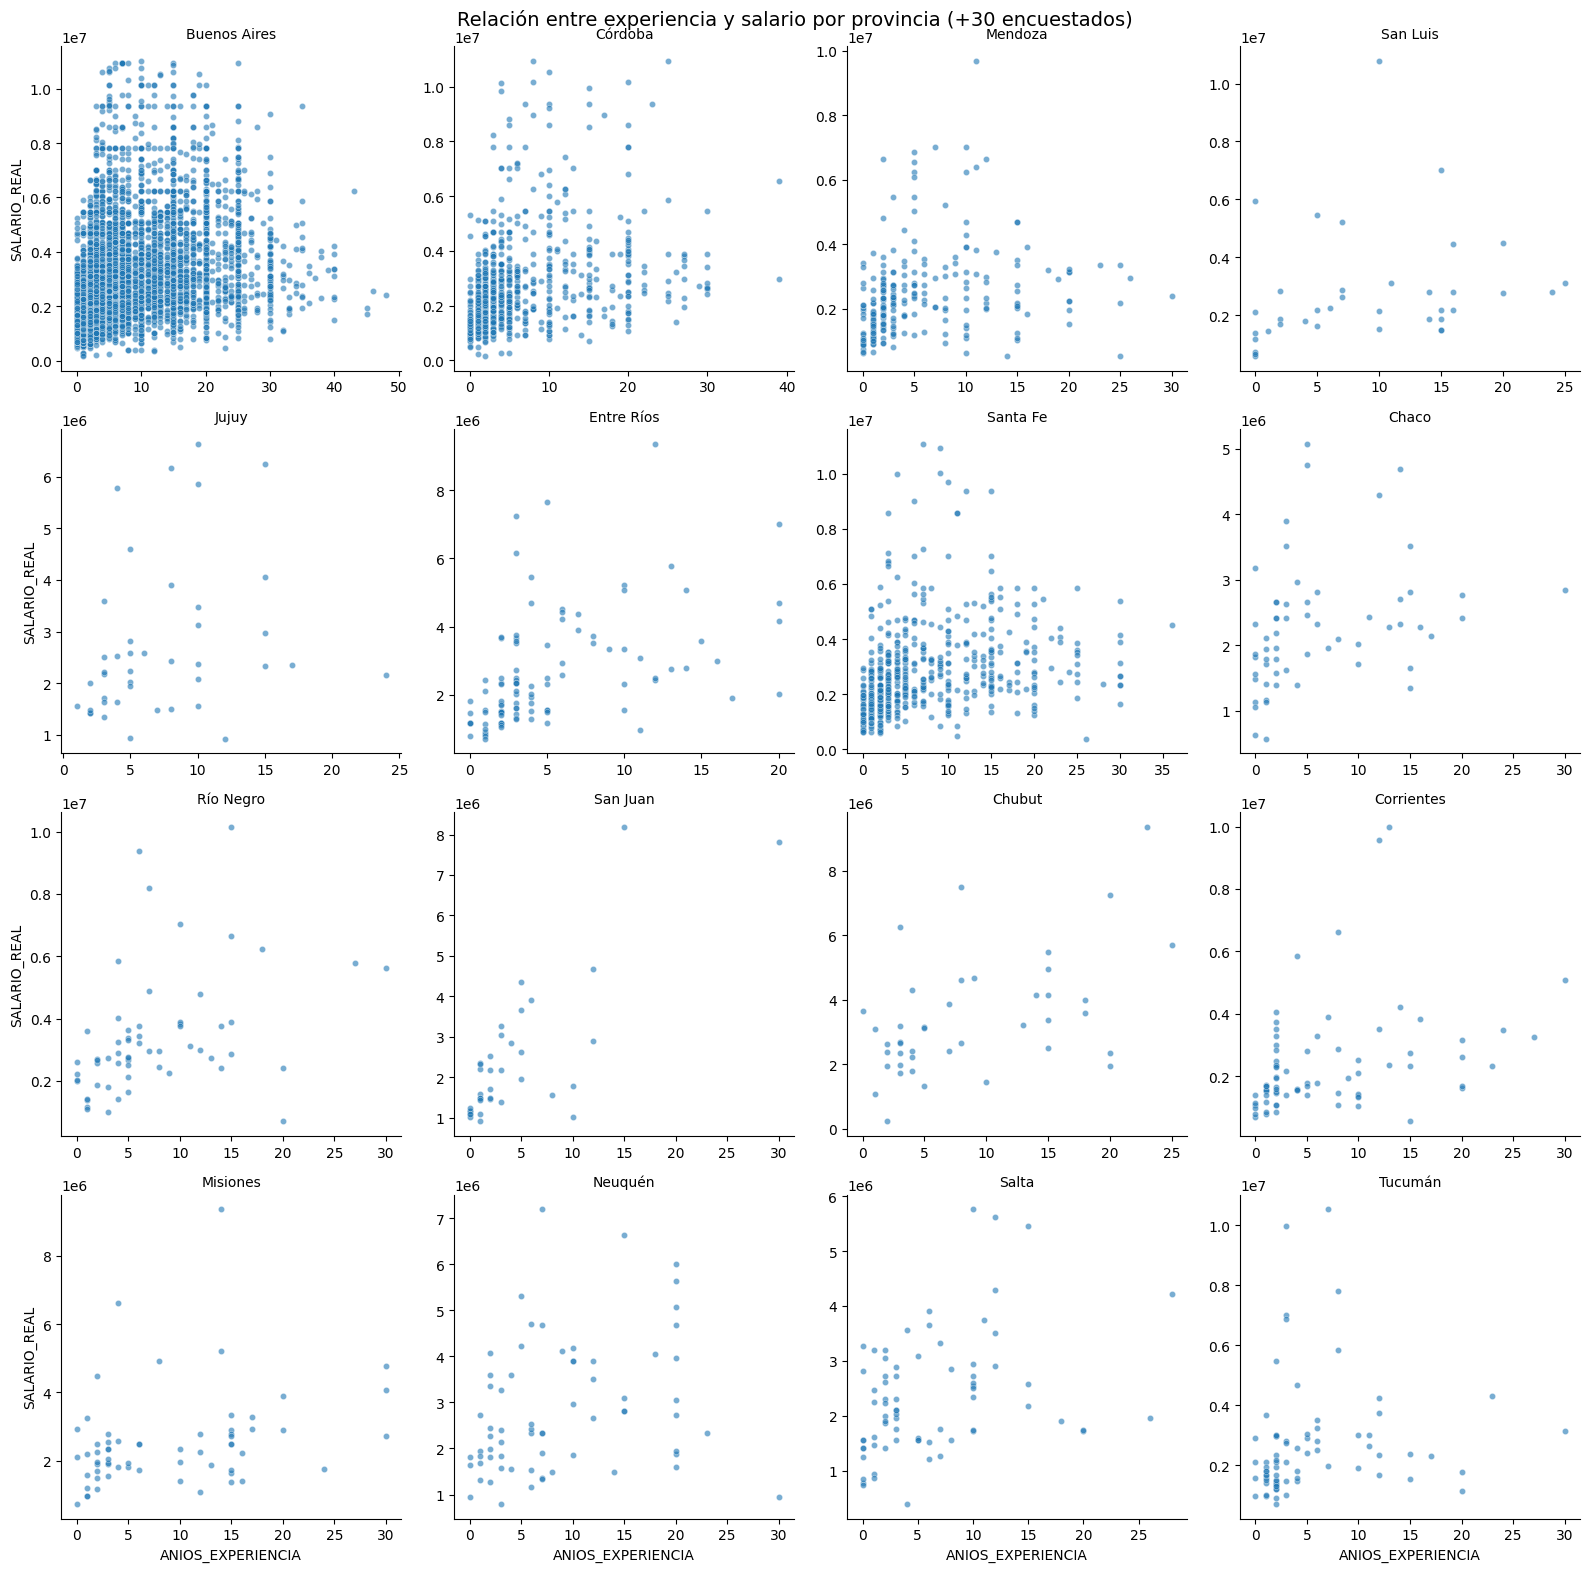

In [54]:
# Filtrar provincias con al menos 30 encuestados
provincia_counts = df["PROVINCIA"].value_counts()
provincias_validas = provincia_counts[provincia_counts >= 30].index
df_filtrado = df[df["PROVINCIA"].isin(provincias_validas)].copy()


g = sns.FacetGrid(
    df_filtrado,
    col="PROVINCIA",
    col_wrap=4,
    height=4,
    sharex=False,
    sharey=False
)

g.map_dataframe(sns.scatterplot, x="ANIOS_EXPERIENCIA", y="SALARIO_REAL", alpha=0.6, s=20)

g.set_titles("{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Relación entre experiencia y salario por provincia (+30 encuestados)", fontsize=14)
plt.tight_layout()
plt.show()

Podemos ver la relacion en buenos aires con relacion entre experiencia y salario

C:\Users\54112\AppData\Local\Temp\ipykernel_25284\393083151.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_rangos = pd.read_sql(query_rangos, conn)
C:\Users\54112\AppData\Local\Temp\ipykernel_25284\393083151.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


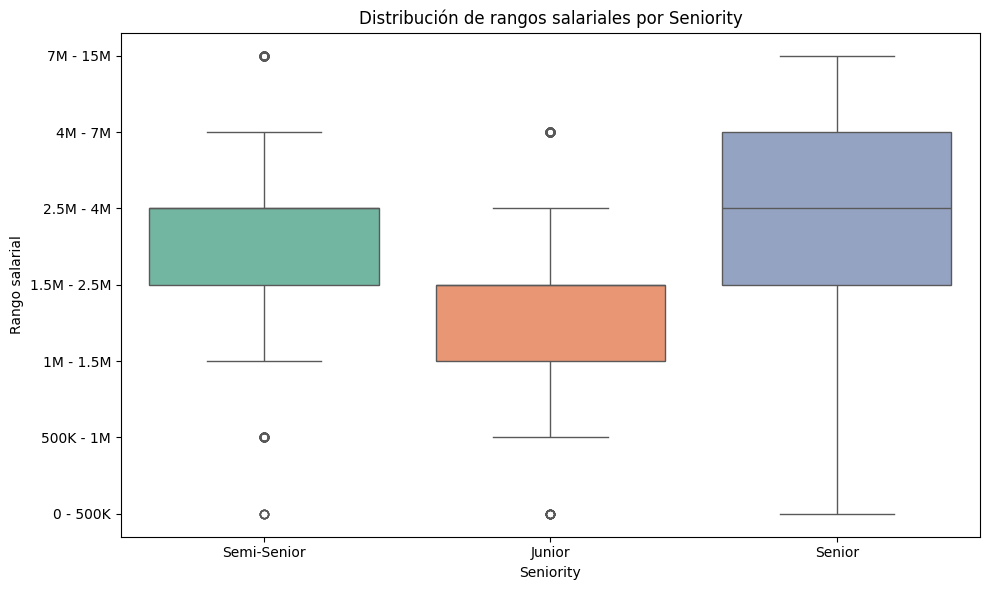

In [ ]:
# Traemos los rangos desde SQL (Preguntar si es mejor asì o como tratarlas)
query_rangos = """
SELECT ID_RANGO_SALARIO, DESCRIPCION
FROM Gold.TBL_RANGO_SALARIO
"""
df_rangos = pd.read_sql(query_rangos, conn)

# Creamos un diccionario para el id y el nombre del rango
rango_dict = dict(zip(df_rangos["ID_RANGO_SALARIO"], df_rangos["DESCRIPCION"]))


df_box = df[df["ID_RANGO_SALARIO"].notna()].copy()

plt.figure(figsize=(10,6))
ax = sns.boxplot(
    data=df_box,
    x="SENIORITY",
    y="ID_RANGO_SALARIO",
    palette="Set2",
    showfliers=True
)

# Reemplazar ticks(y) numéricos por descripciones
ax.set_yticks(sorted(df_box["ID_RANGO_SALARIO"].unique()))
ax.set_yticklabels([rango_dict[i] for i in sorted(df_box["ID_RANGO_SALARIO"].unique())])

plt.title("Distribución de rangos salariales por Seniority")
plt.xlabel("Seniority")
plt.ylabel("Rango salarial")
plt.tight_layout()
plt.show()

En estos graficos podemos notar los rangos salariales de la mayor parte de los encuestados
Además a ponerlos en un rango tan grande igualmente podemos ver algunas excepciones(outliers) dentro de Ssr y Junior, 
pero ¿Porque no se ven en SR? Generalmente a los SR son los mejores pagados aunque pueden haber algunas excepciones en este caso como nosotros establecimos rangos altos debido al ajustes de sueldo por la inflacion, entonces podemos determinar que no hay muchos outliers, es más se concentran en un buen rango salarial

In [20]:
df_box.groupby("SENIORITY")["ID_RANGO_SALARIO"].describe()

,count,mean,std,min,25%,50%,75%,max
SENIORITY,,,,,,,,
Junior,2544.0,3.734670,1.001749,1.0,3.0,4.0,4.0,6.0
Semi-Senior,2007.0,4.557050,1.001300,1.0,4.0,5.0,5.0,7.0
Senior,3620.0,4.950829,1.061945,1.0,4.0,5.0,6.0,7.0


Revisamos por las dudas los datos ya que no vemos las lineas en los otros 2 boxplots pero podemos determinar que la mediana tiene  la linea pegada al borde superior de la caja y no logra ver.
Lo mismo pasa con SSR no se logra a notar.


Ahora veamos cosas relacionadas a satisfaccion laboral para una mejor busqueda de insighst

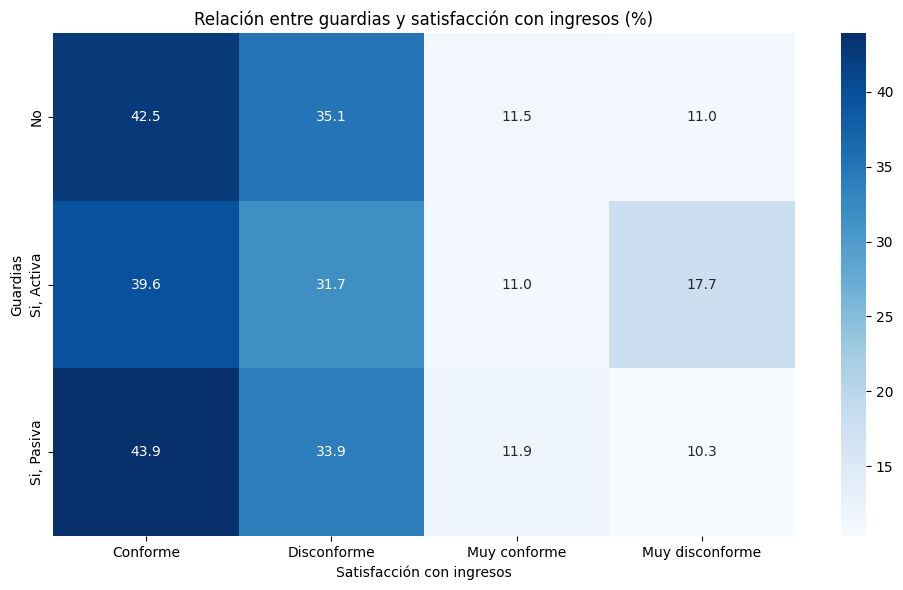

In [ ]:
# Tabla cruzada: Guardias vs Satisfacción con ingresos
tabla_guardias = pd.crosstab(
    df["GUARDIAS"], 
    df["SATISFACCION_INGRESOS"], 
    normalize="index"
) * 100

plt.figure(figsize=(10,6))
sns.heatmap(tabla_guardias, annot=True, fmt=".1f", cmap="Blues")
plt.title("Relación entre guardias y satisfacción con ingresos (%)")
plt.xlabel("Satisfacción con ingresos")
plt.ylabel("Guardias")
plt.tight_layout()
plt.show()


En este grafico podemos notar que satisfacción salarial se mantiene dentro de todo estable entre los que no hacen guardias y los que tienen guardias pasivas, pero cae mucho en quienes realizan guardias activas, donde aparece un 17,7 de empleados muy disconformes con sus ingresos.

Guardias y Salarios

C:\Users\54112\AppData\Local\Temp\ipykernel_25284\556213513.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


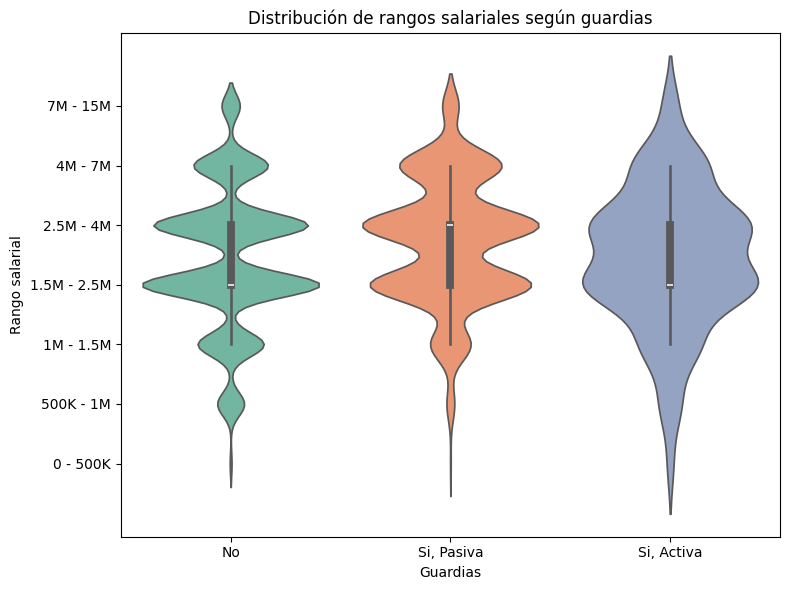

In [ ]:
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df_box, 
    x="GUARDIAS", 
    y="ID_RANGO_SALARIO", 
    inner="box",
    palette="Set2"
)

plt.title("Distribución de rangos salariales según guardias")
plt.xlabel("Guardias")
plt.ylabel("Rango salarial")
plt.yticks(
    ticks=sorted(df_box["ID_RANGO_SALARIO"].unique()),
    labels=[rango_dict[i] for i in sorted(df_box["ID_RANGO_SALARIO"].unique())]
)
plt.tight_layout()
plt.show()

En este grafico lo que podemos notar es que si bien la media esta en un rango parecido encontrmos que hay una mayor concentracion de personas en los que tienen guardias activas
¿Que significa estos? que hay más personas dentro de l rango de 1.5m hasta 7m obviamente sin depender de los senioritys, simplemente es un grafico para calcular que tantas personas tienen
guardas y que tantas personas estan en ese rango, sin embargo podemos notar como si bien los que no tienen guardias al no ternerlas no se les concentran muchas personas en ese rango, es más son más "flacos"
Y bueno las que si tienen pero son pasivas se nota facilmente que tiene un volumen medio entre las 2

¿Se le paga más a los titulados o doctorados etc? ¿Cual es el salario promedio por cada seccion?

C:\Users\54112\AppData\Local\Temp\ipykernel_25284\4263938884.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
C:\Users\54112\AppData\Local\Temp\ipykernel_25284\4263938884.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


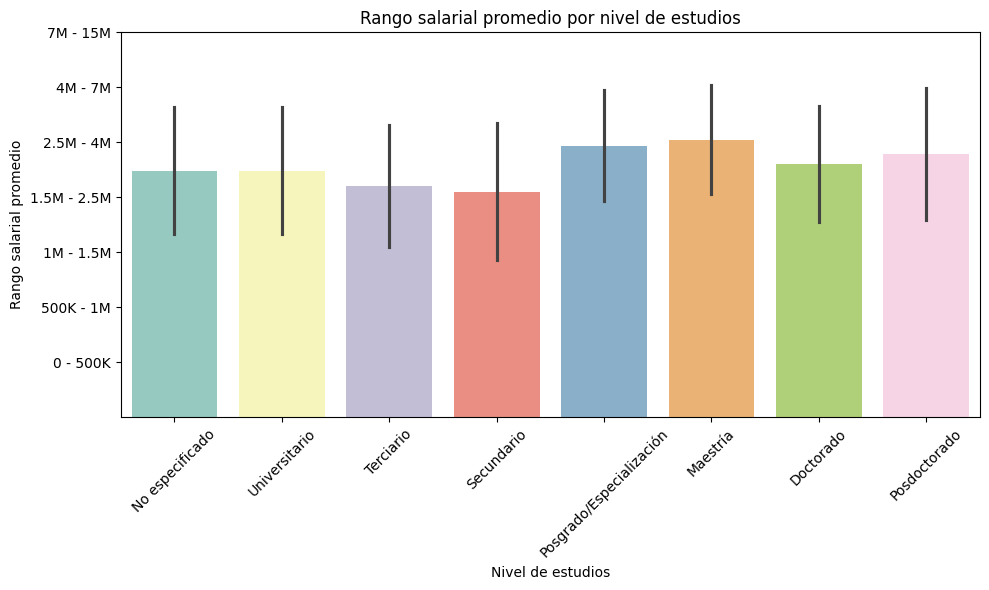

In [ ]:
# Usamos los rangos en vez del salario real
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_box, 
    x="NIVEL_ESTUDIOS", 
    y="ID_RANGO_SALARIO", 
    estimator=np.mean, 
    ci="sd", 
    palette="Set3"
)

plt.title("Rango salarial promedio por nivel de estudios")
plt.ylabel("Rango salarial promedio")
plt.xlabel("Nivel de estudios")
plt.xticks(rotation=45)

# Cambiamos etiquetas del eje Y a descripciones del rango salarial
plt.yticks(
    ticks=sorted(df_box["ID_RANGO_SALARIO"].unique()),
    labels=[rango_dict[i] for i in sorted(df_box["ID_RANGO_SALARIO"].unique())]
)

plt.tight_layout()
plt.show()

Lo que vemos en este grafico es que los "lideran" un salario promedio más "alto" son los que contienen una maestria, posgrado, son los que tiene el salario más alto pero tambien lideran universitario ,doctorado y posdoctorado
, además se ve una breve dominacion de no especificado ¿Quizas podriamos no tormalo en cuenta por lo menos al momento de hacer analisis por provincia?
Obviamente acá no se tiene en cuenta los senioritys.
Las lineas por defectos nos indican un intervalo de confianza de 95% de donde esta la media real de la "poblacion" en este caso seria el salario real de las personas 

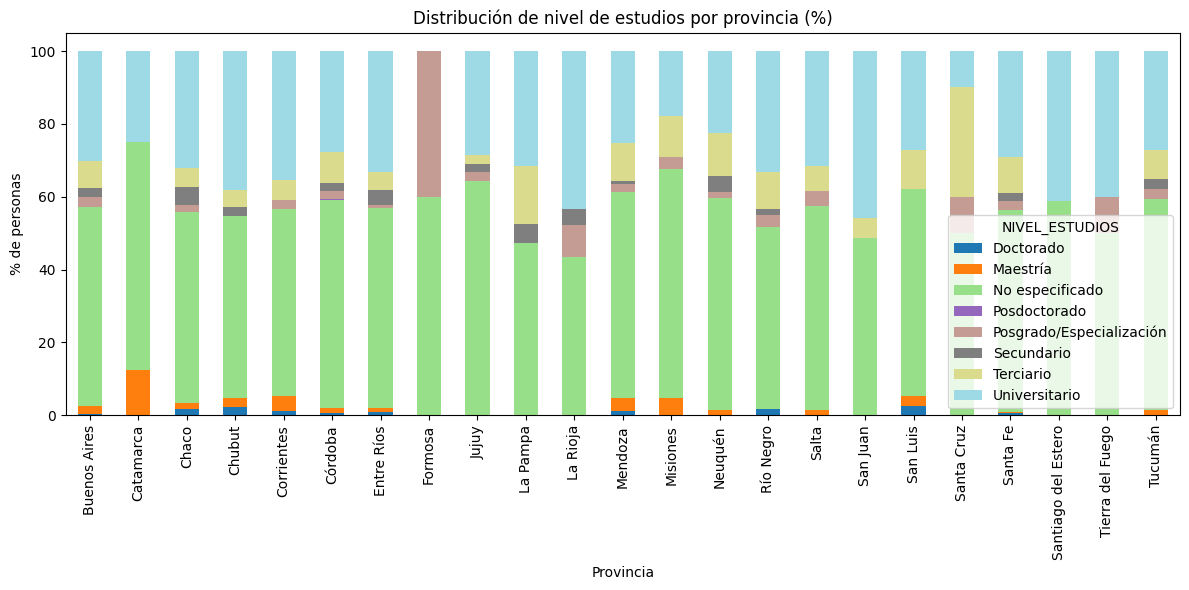

In [ ]:
provincia_counts = df["PROVINCIA"].value_counts()
provincias_validas = provincia_counts[provincia_counts >= 50].index
df_filtrado = df[df["PROVINCIA"].isin(provincias_validas)]
#Graduados por provincia quizas cambiar el grafico
tabla_estudios = pd.crosstab(df["PROVINCIA"], df["NIVEL_ESTUDIOS"], normalize="index") * 100
tabla_estudios.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Distribución de nivel de estudios por provincia (%)")
plt.ylabel("% de personas")
plt.xlabel("Provincia")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Lo que yo entendi acá la distribucion del nivel de estudios por provincia donde claramente domina el universitario en la mayoria peeero en formosa (dato a checkear que no sea solo 1) predomina un posgrado/especializacion
Segunda predominante sería el terciario en la mayoria luego vendria el secundario, se notan pocas maestrias, pocos doctorados y en pocas provincias
¿pero que relevancia tiene este grafico para nuestro analisis?
Basicamente podemos notar que en la mayoria de las provincias predomina el universitario, ahora si queremos buscar Posgrados o especializacion lo mismo, buscariamos en casi todas ya tienen un alto porcentje de personas.
Si nuestra busqeuda está más enfocada en maestrías yy ahí tendriamos que ubicar la busqueda en buenos aires, catamarca, chaco, chubut, corrientes, cordoba, entre rios, mendoza, misiones, neuquen, salta, san luis y tucuman.

¿Como sabemos en que provincia nos conviene contratar universitarios a menor costo? Podriamos calcular el promedio del salario por provincia TENIENDO EN CUENTA solo el nivel de estudios, en este caso Universitarios

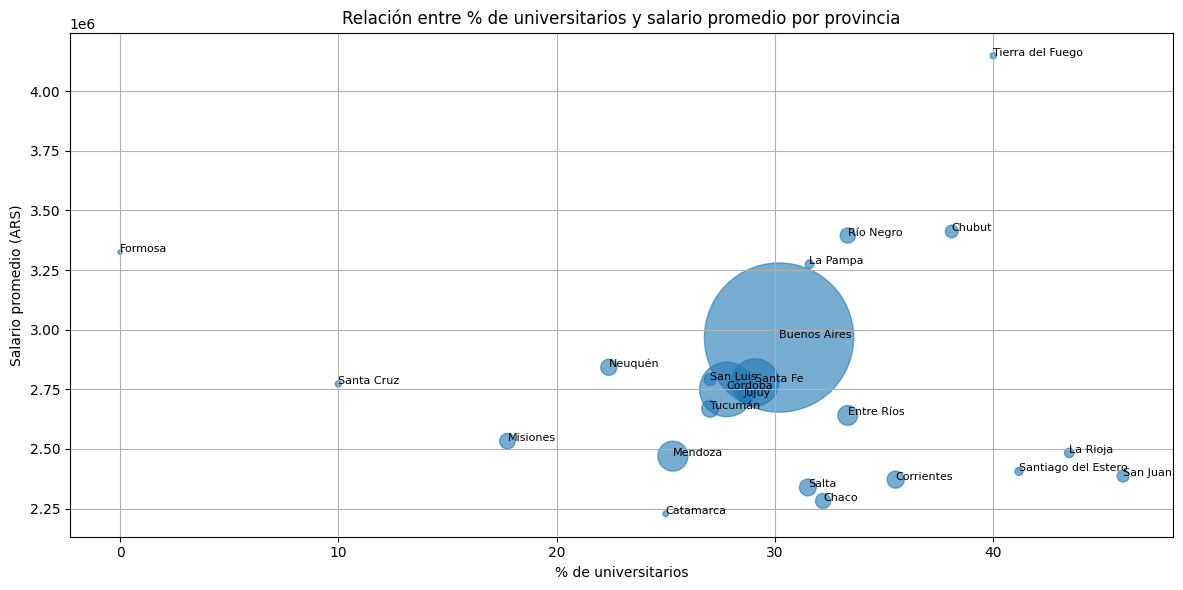

In [ ]:
provincia_counts = df["PROVINCIA"].value_counts()

#Por las dudas filtramos por 50 encuestados
provincias_validas = provincia_counts[provincia_counts >= 50].index
df_filtrado = df[df["PROVINCIA"].isin(provincias_validas)]

salario_prom_prov = (
    df.groupby("PROVINCIA")["SALARIO_REAL"]
    .mean()
    .reset_index()
    .sort_values("SALARIO_REAL", ascending=False)
)


tabla_estudios = pd.crosstab(
    df["PROVINCIA"], 
    df["NIVEL_ESTUDIOS"], 
    normalize="index"
) * 100

tabla_estudios = tabla_estudios.reset_index()
#Cruzamos las tablas para tener el porcentaje de universitarios y el salario promedio por provincia
df_cruce = pd.merge(tabla_estudios, salario_prom_prov, on="PROVINCIA")


#Graficamos el porcentaje de universitarios vs salario promedio
plt.figure(figsize=(12,6))
plt.scatter(
    df_cruce["Universitario"],
    df_cruce["SALARIO_REAL"], 
    s=df["PROVINCIA"].value_counts().loc[df_cruce["PROVINCIA"]]*2,
    alpha=0.6
)

for i, row in df_cruce.iterrows():
    plt.text(row["Universitario"], row["SALARIO_REAL"], row["PROVINCIA"], fontsize=8)

plt.title("Relación entre % de universitarios y salario promedio por provincia")
plt.xlabel("% de universitarios")
plt.ylabel("Salario promedio (ARS)")
plt.grid(True)
plt.tight_layout()
plt.show()

En este grafico podemos notar (los encuestados por su tamaño de burbuja) en este caso se nota que en la rioja santiago del estero y san juan hay más porcentaje de universitarios pero con salario bajos lo cual es una gran oportunidad de contratacion.... esto sin tener en cuenta los senioritys obviamente
y hay más burbujas llamativas pero son chicas, podemos notar que buenos aires contiene un gran porcentaje de encuestados y gran porcentaje de universitarios    


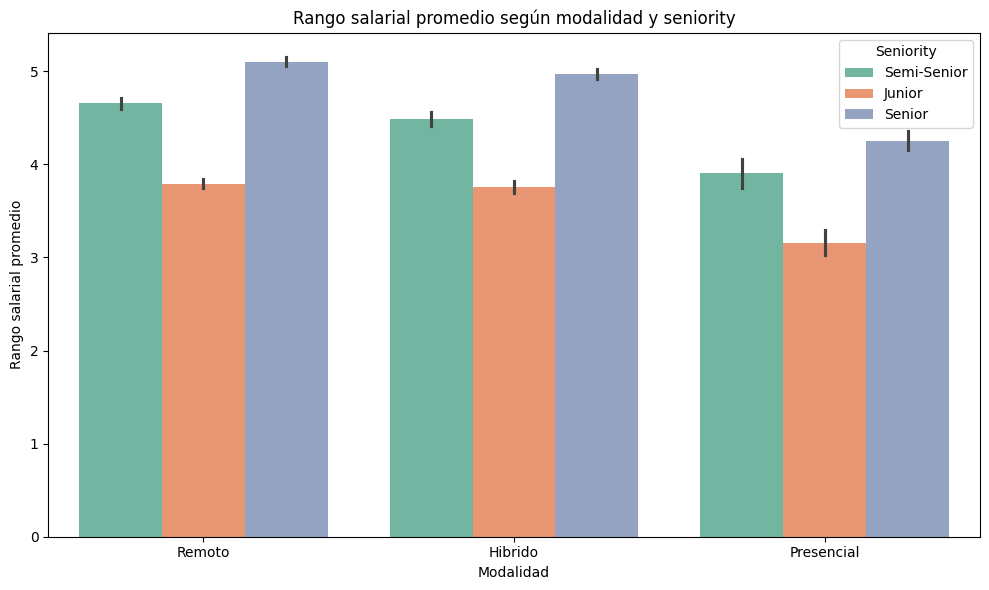

In [50]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=df, 
    x="MODALIDAD", 
    y="ID_RANGO_SALARIO",
    hue="SENIORITY",
    estimator=np.mean,  
    palette="Set2"
)

plt.title("Rango salarial promedio según modalidad y seniority")
plt.ylabel("Rango salarial promedio")
plt.xlabel("Modalidad")
plt.legend(title="Seniority")
plt.tight_layout()
plt.show()


En este grafico podemos notar que senioritys predominan la modalidad de trabajo en este caso vemos que por amplia diferencia gana remoto, ya sea en SR, en ssr y en junior.
Hibrido no se queda atrás presencial es el que menos tiene pero hay que tener en cuenta que esta encuesta es de 2023, actualmente esto viene cambiando y las empresas buscan volver a la presencialidad

In [ ]:
#Verificamos por las dudas los datos exactos de la modalidad
tabla_modalidad = (
    df.groupby(["MODALIDAD", "SENIORITY"])["ID_RANGO_SALARIO"]
    .mean()
    .reset_index()
    .sort_values(["MODALIDAD","SENIORITY"])
)

tabla_modalidad["RANGO_PROMEDIO"] = (
    tabla_modalidad["ID_RANGO_SALARIO"].round().astype(int).map(rango_dict)
)

tabla_modalidad

,MODALIDAD,SENIORITY,ID_RANGO_SALARIO,RANGO_PROMEDIO
0,Hibrido,Junior,3.755915,1.5M - 2.5M
1,Hibrido,Semi-Senior,4.486111,1.5M - 2.5M
2,Hibrido,Senior,4.969849,2.5M - 4M
3,Presencial,Junior,3.157303,1M - 1.5M
4,Presencial,Semi-Senior,3.907563,1.5M - 2.5M
5,Presencial,Senior,4.255000,1.5M - 2.5M
6,Remoto,Junior,3.789507,1.5M - 2.5M
7,Remoto,Semi-Senior,4.656452,2.5M - 4M
8,Remoto,Senior,5.103194,2.5M - 4M


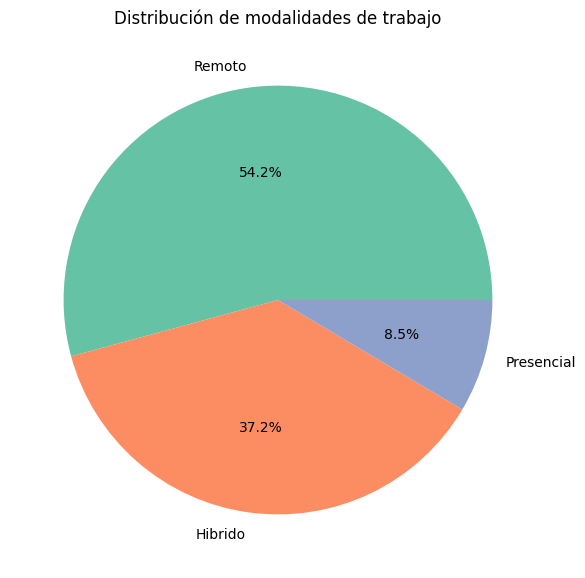

In [27]:
# Distribución de modalidades
plt.figure(figsize=(6,6))
df["MODALIDAD"].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=sns.color_palette("Set2"))
plt.title("Distribución de modalidades de trabajo")
plt.ylabel("")
plt.tight_layout()
plt.show()

Podemos observar como la modalidad remoto actualmente dominando la mayor parte y presencial se esta quedando un poco chico pero no significa que 
¿Como podriamos explicar esto? ya que es en 2023 actualmente cada vez mas empresas estan volviendo a la presencialidad, así que no sería tan bueno quizas esto

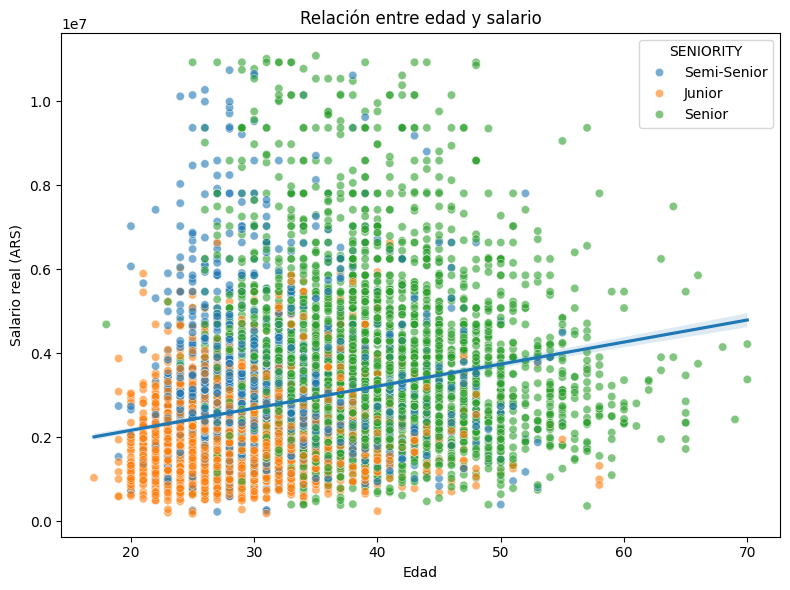

In [61]:
#Verificar nuevamente lo de rangos de salarios porque ahora aparece 1e7, quizas es mejor usar el id del rango salarial
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, 
    x="EDAD", 
    y="SALARIO_REAL", 
    hue="SENIORITY", 
    alpha=0.6
)
sns.regplot(
    data=df, 
    x="EDAD", 
    y="SALARIO_REAL", 
    scatter=False, 
)
plt.title("Relación entre edad y salario")
plt.xlabel("Edad")
plt.ylabel("Salario real (ARS)")
plt.tight_layout()
plt.show()

En este grafico podemos notar ampliamente como los "juiors" de menor edad generalmente suelen tener un salario real, además vemos como semisenior esta un poco más arriba  y vemos una dominacion de senior generalmente tirando arriba y podemos notar datos outliers como un senior de menos de 20...

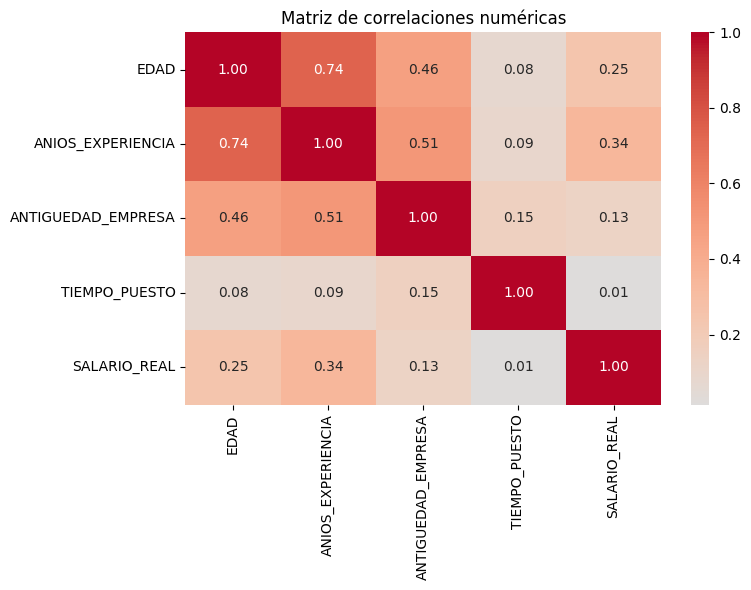

In [ ]:
# Seleccionamos solo columnas numéricas relevantes para buscar las colunmas correlacionadas
corr_cols = ["EDAD", "ANIOS_EXPERIENCIA", "ANTIGUEDAD_EMPRESA", "TIEMPO_PUESTO", "SALARIO_REAL"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlaciones numéricas")
plt.tight_layout()
plt.show()

En base a este grafico podemos afirmar que el salario it esta mas conectado al seniority y la capacidad de cambiar de empresa o rol.
Para una empresa que busca atraer talento a un costo menor, esto nos indica que podemo encontrar perfiles con mucha experiencia pero que todavía no alcanzan los rangos salariales más altos.
Resumiendo: Para lograr una buena contratacion y retener tenemos que enfocarnos en la la estrategia de contratación, identificar perfiles con alto potencial y experiencia, más que en priorizar la "estadía" en una misma empresa.
Obviamente dependiendo de nuestra busqueda..

ANALIZAR ESTO QUE ES BUENISIMO

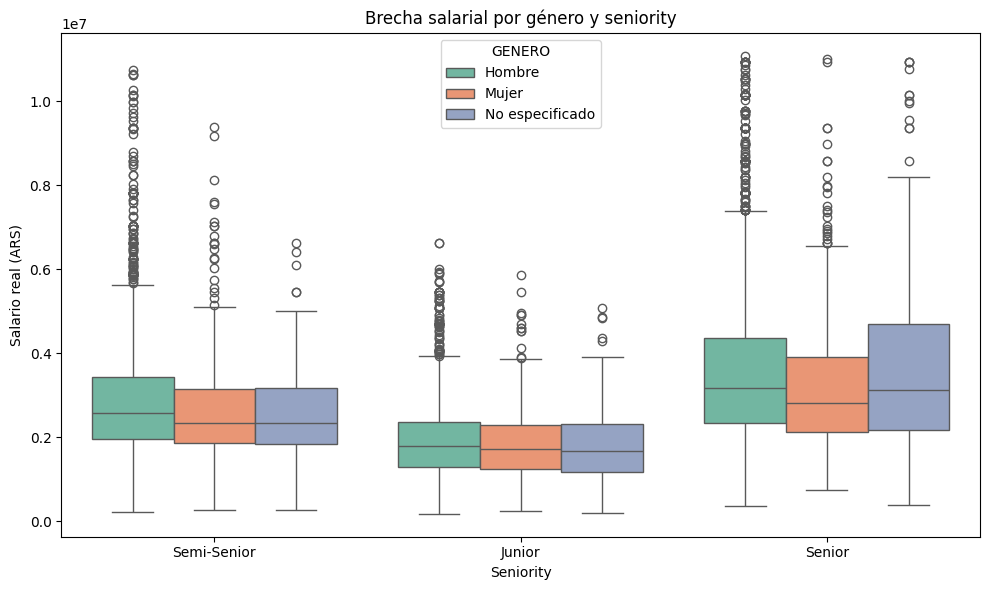

In [64]:
#El violin plot no me gusto, es más el otro si porque lo pude entender de buena manera solo falta anlizarlo bien buscar otro grafico apra la distribucion de salario entre hombre y mujer o buscar explicacion del violinplot

#comparando por seniority por las dudas
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df, 
    x="SENIORITY", 
    y="SALARIO_REAL", 
    hue="GENERO", 
    palette="Set2"
)
plt.title("Brecha salarial por género y seniority")
plt.xlabel("Seniority")
plt.ylabel("Salario real (ARS)")
plt.tight_layout()
plt.show()

Lo que podemos notar es que si bien en distintos senioritis sueeelen coincidir, por lo menos en junior estan muy a la par la media, pero podemos notar que los hombres tienen outliers
En el Ssr podemos notar como tiene un poco más alto el Hombre y además muchisimo outliers, en este caso suelen haber un poco  mas outliers de las mujeres.

Ya en senior cambia un poco(vamos a ignorar el no especificado) pero podemos otar como sigue teniendo un poco más de outliers los hombres y un poquito mas las mujeres
La brecha salarial no se nota tanto en la mediana, sino en la dispersión: los hombres presentan con mayor frecuencia casos extremos de sueldos más altos,en especial cuadno aumenta el seniority.